# Forecast de ventas con Prophet

Genera una prediccion de 60 dias usando Facebook Prophet con estacionalidad semanal y anual.
El resultado se guarda en la coleccion `forecasts` de MongoDB para que el dashboard lo consuma.

**Dependencias:**
```
pip install prophet pymongo pandas python-dotenv matplotlib
```

In [53]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pymongo import MongoClient
from prophet import Prophet

load_dotenv('../DBNOSQL_Proyecto/.env.local')

MONGODB_URI = os.getenv('MONGODB_URI')
if not MONGODB_URI:
    raise ValueError('MONGODB_URI no encontrado en .env.local')

print('URI cargada correctamente')

URI cargada correctamente


In [54]:
client = MongoClient(MONGODB_URI)
db = client['pizzaDB']
menu = db['menu']

pipeline = [
    {'$match': {'order_date': {'$exists': True}, 'quantity': {'$gt': 0}}},
    {'$addFields': {'date': {'$toDate': '$order_date'}}},
    {
        '$group': {
            '_id': {'$dateToString': {'format': '%Y-%m-%d', 'date': '$date'}},
            'total': {'$sum': '$quantity'}
        }
    },
    {'$sort': {'_id': 1}}
]

registros = list(menu.aggregate(pipeline))
df_raw = pd.DataFrame(registros).rename(columns={'_id': 'ds', 'total': 'y'})
df_raw['ds'] = pd.to_datetime(df_raw['ds'])

print(f'Dias de historico: {len(df_raw)}')
print(f'Rango: {df_raw["ds"].min().date()} a {df_raw["ds"].max().date()}')
print(f'Media: {df_raw["y"].mean():.1f} | Mediana: {df_raw["y"].median():.1f} | Std: {df_raw["y"].std():.1f}')
print(f'Min: {df_raw["y"].min()} | Max: {df_raw["y"].max()}')

c:\Users\Jhoshua\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymongo\pyopenssl_context.py:348: CryptographyDeprecationWarning: Parsed a serial number which wasn't positive (i.e., it was negative or zero), which is disallowed by RFC 5280. Loading this certificate will cause an exception in a future release of cryptography.
  _crypto.X509.from_cryptography(x509.load_der_x509_certificate(cert))


Dias de historico: 358
Rango: 2015-01-01 a 2015-12-31
Media: 142.5 | Mediana: 133.5 | Std: 77.9
Min: 56.0 | Max: 711.0


## Limpieza de outliers

Los datos sinteticos tienen picos artificiales (dias con ventas extremas) que distorsionan
el modelo si se entrenan tal cual. Los capamos con el metodo IQR antes de entrenar.

In [55]:
p01 = df_raw["y"].quantile(0.01)
p99 = df_raw["y"].quantile(0.99)

df = df_raw.copy()
# Outliers extremos -> NaN: Prophet los ignora al entrenar pero los grafica
df.loc[(df["y"] > p99) | (df["y"] < p01), "y"] = None

n_nan = df["y"].isna().sum()
print(f"p01: {p01:.1f} | p99: {p99:.1f}")
print(f"Dias marcados como NaN (outliers extremos): {n_nan}")
print(f"Media sin outliers: {df["y"].mean():.1f} | Max: {df["y"].max():.1f}")


p01: 65.8 | p99: 442.2
Dias marcados como NaN (outliers extremos): 8
Media sin outliers: 139.1 | Max: 437.0


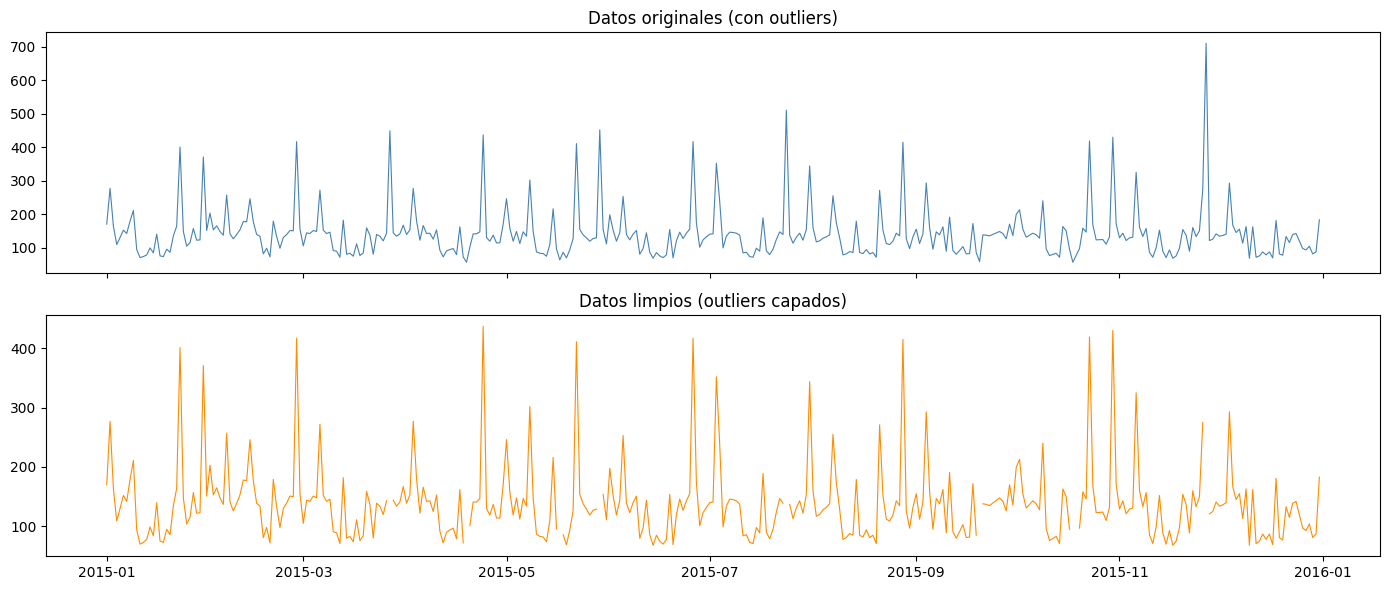

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df_raw['ds'], df_raw['y'], linewidth=0.8, color='steelblue')
axes[0].set_title('Datos originales (con outliers)')
axes[1].plot(df['ds'], df['y'], linewidth=0.8, color='darkorange')
axes[1].set_title('Datos limpios (outliers capados)')
plt.tight_layout()
plt.show()

## Entrenamiento del modelo

In [57]:
modelo = Prophet(
    seasonality_mode="multiplicative",
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,   # tendencia estable, sin reaccionar a picos
    seasonality_prior_scale=50.0,
    interval_width=0.90,
    uncertainty_samples=500
)

# Estacionalidad mensual (captura la bajada de mediados de mes)
modelo.add_seasonality(name="monthly", period=30.5, fourier_order=5)

# Regressor viernes (pico semanal fuerte)
df["es_viernes"] = (df["ds"].dt.dayofweek == 4).astype(int)
modelo.add_regressor("es_viernes", prior_scale=30.0, mode="multiplicative")

modelo.fit(df)
print("Modelo entrenado")


00:50:04 - cmdstanpy - INFO - Chain [1] start processing
00:50:04 - cmdstanpy - INFO - Chain [1] done processing


Modelo entrenado


In [58]:
futuro = modelo.make_future_dataframe(periods=90)
futuro["es_viernes"] = (futuro["ds"].dt.dayofweek == 4).astype(int)
pronostico = modelo.predict(futuro)

solo_futuro = pronostico[pronostico["ds"] > df["ds"].max()].copy()

print(f"Dias pronosticados: {len(solo_futuro)}")
print(f"Rango del forecast: {solo_futuro["ds"].min().date()} a {solo_futuro["ds"].max().date()}")
print(f"Mean rango: {solo_futuro["yhat"].min():.1f} - {solo_futuro["yhat"].max():.1f}")
print(f"CI rango: {solo_futuro["yhat_lower"].min():.1f} - {solo_futuro["yhat_upper"].max():.1f}")
solo_futuro[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(7)


Dias pronosticados: 90
Rango del forecast: 2016-01-01 a 2016-03-30
Mean rango: 48.5 - 300.6
CI rango: -10.4 - 355.6


,ds,yhat,yhat_lower,yhat_upper
358,2016-01-01,275.624851,223.314251,330.142336
359,2016-01-02,146.080689,87.300131,209.618864
360,2016-01-03,115.975317,58.911209,167.786544
361,2016-01-04,129.939633,70.720872,189.343237
362,2016-01-05,127.352398,70.483211,186.862738
363,2016-01-06,132.918094,74.625189,191.558188
364,2016-01-07,141.663014,87.062743,198.949216


## Visualizacion

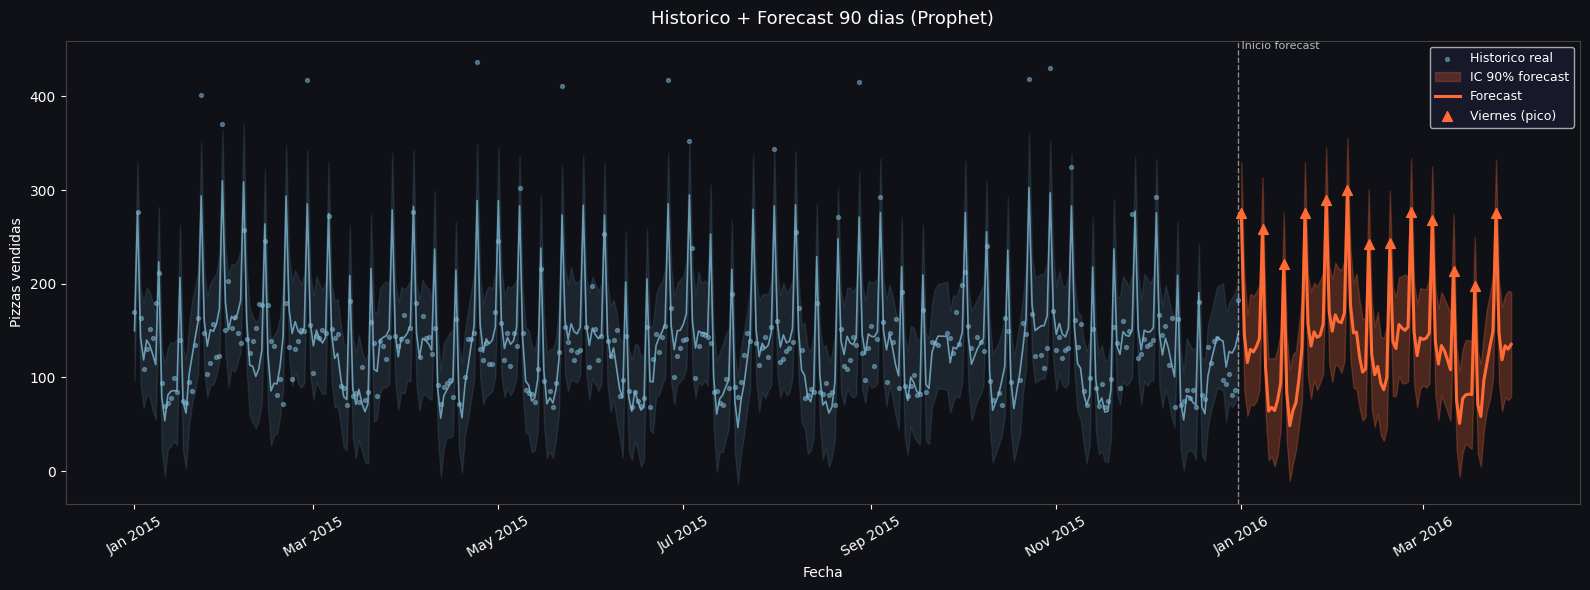

In [59]:
import matplotlib.dates as mdates

# Separar historico y forecast
hist = pronostico[pronostico["ds"] <= df["ds"].max()].copy()
fut  = pronostico[pronostico["ds"] >  df["ds"].max()].copy()

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_facecolor("#0f1117")
fig.patch.set_facecolor("#0f1117")

# --- Historico ---
# Puntos reales
ax.scatter(df["ds"], df["y"], color="#7eb8d4", s=8, alpha=0.5, zorder=3, label="Historico real")
# Linea fitted
ax.plot(hist["ds"], hist["yhat"], color="#7eb8d4", linewidth=1.2, alpha=0.8)
# CI historico
ax.fill_between(hist["ds"], hist["yhat_lower"], hist["yhat_upper"],
               color="#7eb8d4", alpha=0.12)

# Linea divisoria
ax.axvline(df["ds"].max(), color="white", linestyle="--", linewidth=1, alpha=0.5)
ax.text(df["ds"].max(), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 500,
        " Inicio forecast", color="white", fontsize=8, va="top", alpha=0.7)

# --- Forecast ---
# CI forecast
ax.fill_between(fut["ds"], fut["yhat_lower"], fut["yhat_upper"],
               color="#ff6b35", alpha=0.25, label="IC 90% forecast")
# Linea forecast
ax.plot(fut["ds"], fut["yhat"], color="#ff6b35", linewidth=2.2, label="Forecast")

# Marcar viernes del forecast
vie_fut = fut[fut["ds"].dt.dayofweek == 4]
ax.scatter(vie_fut["ds"], vie_fut["yhat"], color="#ff6b35", s=50,
           zorder=5, marker="^", label="Viernes (pico)")

ax.set_title("Historico + Forecast 90 dias (Prophet)", color="white", fontsize=13, pad=12)
ax.set_xlabel("Fecha", color="white")
ax.set_ylabel("Pizzas vendidas", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#444")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


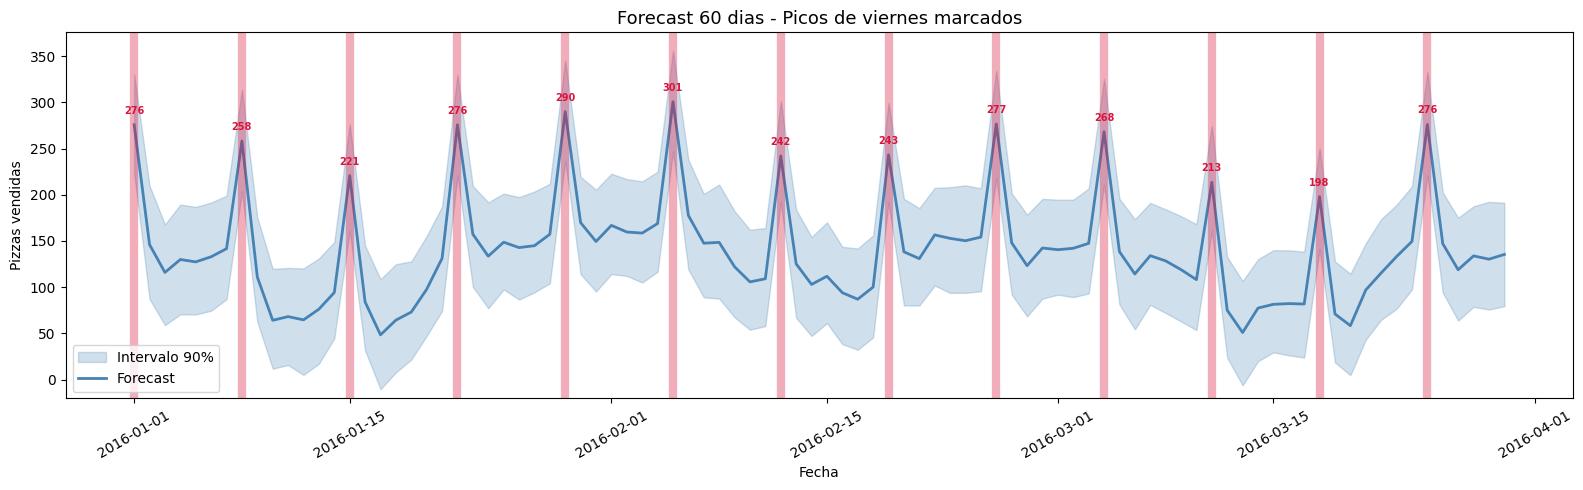

Viernes - media forecast: 256.8
Domingo - media forecast: 104.5
Diferencia Vi-Do: 152.2 pizzas


In [60]:
import matplotlib.patches as mpatches

# Solo los 60 dias del forecast
sf = solo_futuro.copy()
sf["es_viernes"] = sf["ds"].dt.dayofweek == 4
sf["es_domingo"] = sf["ds"].dt.dayofweek == 6

fig, ax = plt.subplots(figsize=(16, 5))

# Banda de confianza
ax.fill_between(sf["ds"], sf["yhat_lower"], sf["yhat_upper"],
               alpha=0.25, color="steelblue", label="Intervalo 90%")

# Linea del forecast
ax.plot(sf["ds"], sf["yhat"], color="steelblue", linewidth=2, label="Forecast")

# Marcar viernes con barras verticales
for _, row in sf[sf["es_viernes"]].iterrows():
    ax.axvline(row["ds"], color="crimson", alpha=0.35, linewidth=6)
    ax.annotate(f"{row['yhat']:.0f}",
               xy=(row["ds"], row["yhat"]),
               xytext=(0, 8), textcoords="offset points",
               ha="center", fontsize=7, color="crimson", fontweight="bold")

ax.set_title("Forecast 60 dias - Picos de viernes marcados", fontsize=13)
ax.set_ylabel("Pizzas vendidas")
ax.set_xlabel("Fecha")
ax.legend()
ax.set_ylim(sf["yhat_lower"].min() - 10, sf["yhat_upper"].max() + 20)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Stats
print("Viernes - media forecast:", sf[sf["es_viernes"]]["yhat"].mean().round(1))
print("Domingo - media forecast:", sf[sf["es_domingo"]]["yhat"].mean().round(1))
print("Diferencia Vi-Do:", (sf[sf["es_viernes"]]["yhat"].mean() - sf[sf["es_domingo"]]["yhat"].mean()).round(1), "pizzas")


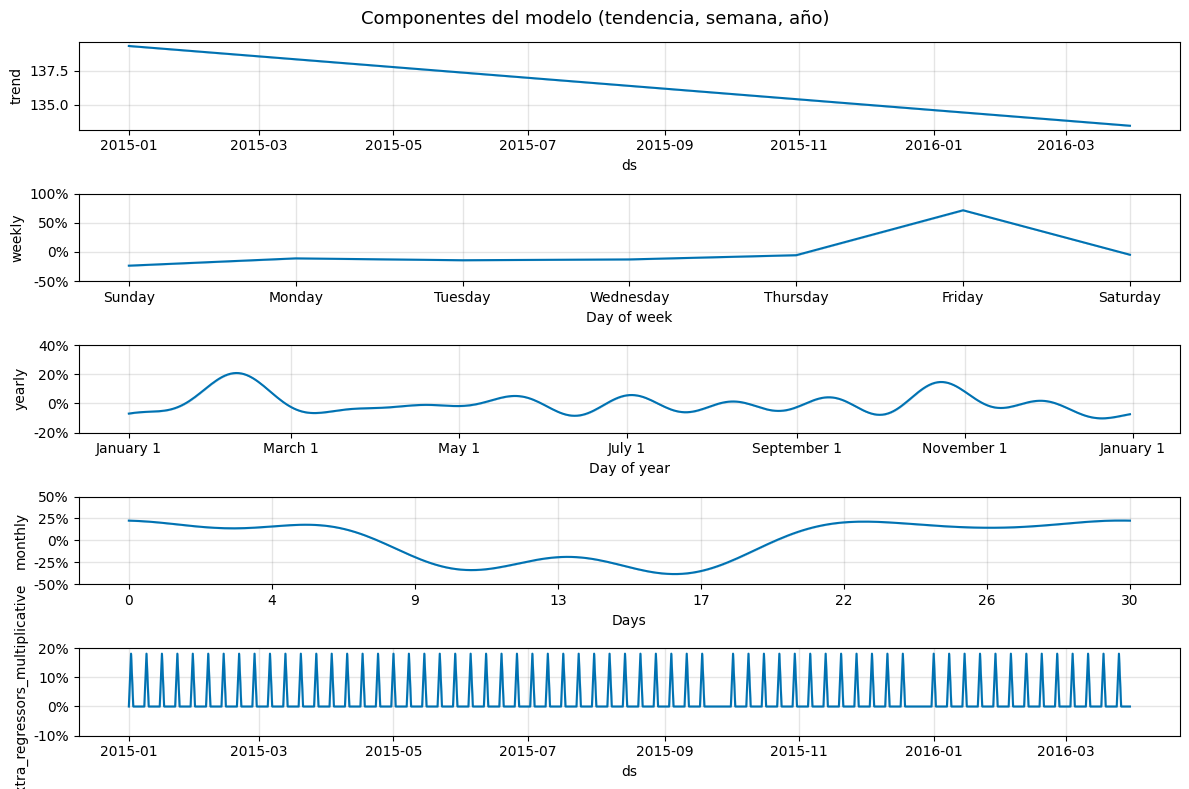

In [61]:
fig_comp = modelo.plot_components(pronostico, figsize=(12, 8))
fig_comp.suptitle('Componentes del modelo (tendencia, semana, año)', fontsize=13)
plt.tight_layout()
plt.show()

## Guardar en MongoDB

In [62]:
documentos = []
for _, fila in solo_futuro.iterrows():
    documentos.append({
        'date': fila['ds'].strftime('%Y-%m-%d'),
        'mean': round(max(float(fila['yhat']), 0), 2),
        'min':  round(max(float(fila['yhat_lower']), 0), 2),
        'max':  round(max(float(fila['yhat_upper']), 0), 2),
    })

col_forecast = db['forecasts']
col_forecast.drop()
col_forecast.insert_many(documentos)

print(f'{len(documentos)} documentos guardados en pizzaDB.forecasts')
client.close()

90 documentos guardados en pizzaDB.forecasts
